<a href="https://colab.research.google.com/github/riyarani6180/multipleLinearRegression/blob/main/Multiple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
df_index = pd.read_csv('/economic_index.csv')


In [ ]:
df_index.head()

,Year,Interest_Rate,Unemployment_Rate,Stock_Index
0,2000,6.5,5.8,1200
1,2001,6.0,6.0,1150
2,2002,5.5,6.2,1180
3,2003,5.0,6.0,1250
4,2004,4.8,5.5,1350


In [ ]:
## drop unnecessary columns
df_index.drop(columns=['Year'], axis=1, inplace=True)

In [ ]:
df_index.head()

,Interest_Rate,Unemployment_Rate,Stock_Index
0,6.5,5.8,1200
1,6.0,6.0,1150
2,5.5,6.2,1180
3,5.0,6.0,1250
4,4.8,5.5,1350


In [ ]:
## checking null values
df_index.isnull().sum()

,0
Interest_Rate,0
Unemployment_Rate,0
Stock_Index,0


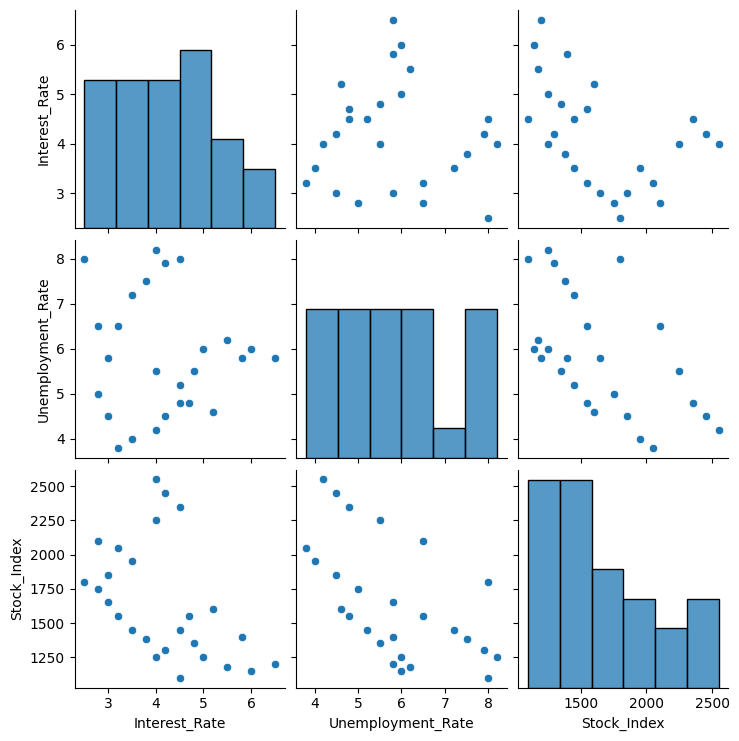

In [ ]:
## visulalization
import seaborn as sns
sns.pairplot(df_index)

In [ ]:
df_index.corr()

,Interest_Rate,Unemployment_Rate,Stock_Index
Interest_Rate,1.000000,-0.053549,-0.467154
Unemployment_Rate,-0.053549,1.000000,-0.573736
Stock_Index,-0.467154,-0.573736,1.000000


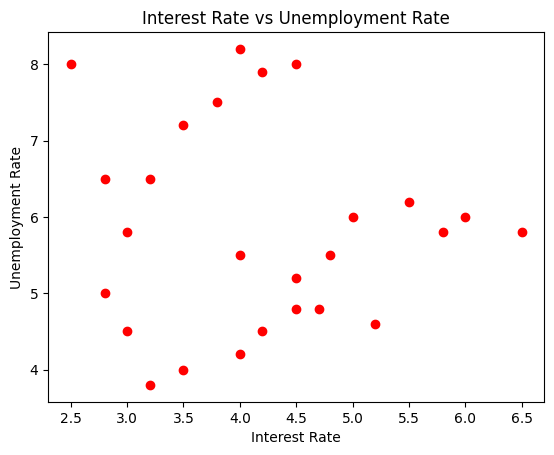

In [ ]:
## visualixw the data more closely
plt.scatter(df_index['Interest_Rate'], df_index['Unemployment_Rate'],color='r')
plt.xlabel('Interest Rate')
plt.ylabel('Unemployment Rate')
plt.title('Interest Rate vs Unemployment Rate')
plt.show()

In [ ]:
## independent and dependent features
X = df_index.iloc[:,:-1]
y = df_index.iloc[:,-1]

In [ ]:
X.head()

,Interest_Rate,Unemployment_Rate
0,6.5,5.8
1,6.0,6.0
2,5.5,6.2
3,5.0,6.0
4,4.8,5.5


In [ ]:
y.head()

,Stock_Index
0,1200
1,1150
2,1180
3,1250
4,1350


In [ ]:
## train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [ ]:
import seaborn as sns
sns.regplot(df_index['Interest_Rate'], df_index['Unemployment_Rate'],color='r')
plt.xlabel('Interest Rate')
plt.ylabel('Unemployment Rate')
plt.title('Interest Rate vs Unemployment Rate')
plt.show()

TypeError: regplot() takes from 0 to 1 positional arguments but 2 positional arguments (and 1 keyword-only argument) were given

In [ ]:
## standeralization
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
X_train

array([[-0.8022796 , -1.26054176],
       [-1.08543711, -1.41810947],
       [-1.46298045, -0.47270316],
       [ 1.55736629,  0.31513544],
       [-0.33035042,  2.04838035],
       [-0.33035042, -1.10297404],
       [-0.14157875, -0.86662246],
       [ 1.36859462,  0.15756772],
       [ 0.33035042, -0.63027088],
       [ 0.42473626, -0.07878386],
       [ 0.14157875,  1.89081263],
       [ 0.8022796 , -0.7878386 ],
       [ 0.14157875, -0.63027088],
       [ 0.61350793,  0.31513544],
       [ 2.02929547,  0.15756772],
       [-1.46298045,  0.70905474],
       [-1.27420878,  0.15756772],
       [-0.5191221 ,  1.49689333]])

In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
## cross validation
from sklearn.model_selection import cross_val_score
scores = cross_val_score(lr, X_train, y_train, cv=3,scoring='r2')
np.mean(scores)

np.float64(0.4968719790742712)

In [ ]:
scores

array([0.37576552, 0.60996026, 0.50489017])

In [ ]:
## prediction
y_pred=lr.predict(X_test)


In [ ]:
y_pred

array([1319.79871547, 1497.42349816, 1693.09455837, 2170.38779093,
       1730.29118798, 1194.78103296, 1759.89531842, 1482.12576371])

In [ ]:
### performance metrices
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
print('MAE:', mean_absolute_error(y_test, y_pred))
print('MSE:', mean_squared_error(y_test, y_pred))
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

MAE: 226.69977086503815
MSE: 70636.18177592066


0.3263020083067937

In [ ]:
## adjusted r square
print('Adjusted R Square:',1 - (1-r2_score(y_test, y_pred))*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))

Adjusted R Square: 0.056822811629511194


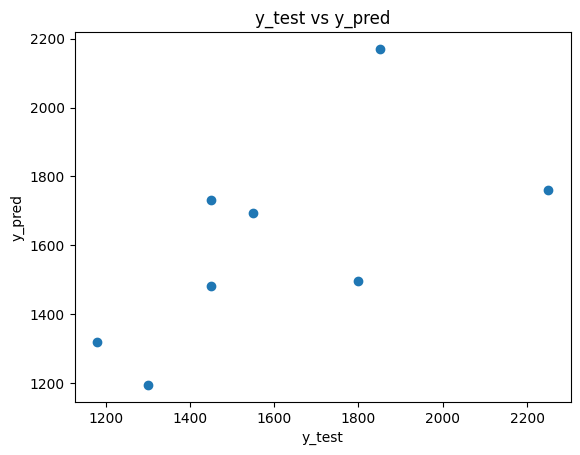

In [ ]:
## assumption
plt.scatter(y_test,y_pred)
plt.xlabel('y_test')
plt.ylabel('y_pred')
plt.title('y_test vs y_pred')
plt.show()

In [ ]:
resudials=y_test-y_pred
print(resudials)

2    -139.798715
20    302.576502
14   -143.094558
17   -320.387791
5    -280.291188
11    105.218967
22    490.104682
13    -32.125764
Name: Stock_Index, dtype: float64


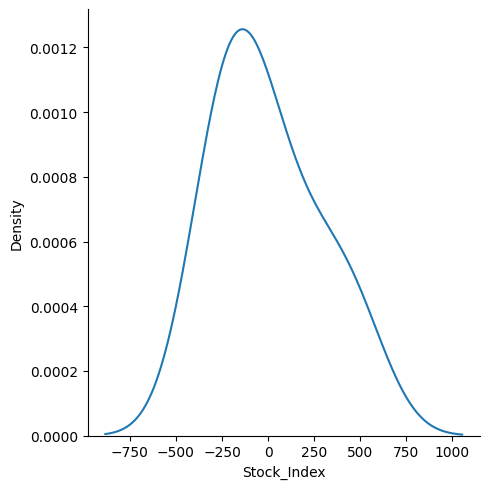

In [ ]:
## plot
sns.displot(resudials,kind='kde')

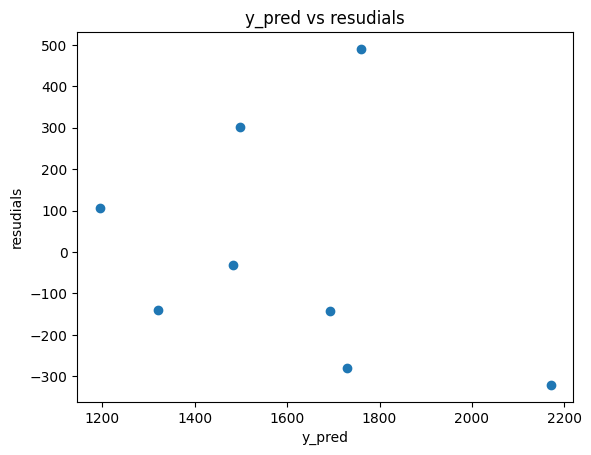

In [ ]:
## catter plot with respect to prediction and residuals
plt.scatter(y_pred,resudials)
plt.xlabel('y_pred')
plt.ylabel('resudials')
plt.title('y_pred vs resudials')
plt.show()

In [ ]:
## OLS Linear Regression
import statsmodels.api as sm
X_train_sm = sm.add_constant(X_train)
lr_1 = sm.OLS(y_train, X_train_sm).fit()
lr_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            Stock_Index   R-squared:                       0.623
Model:                            OLS   Adj. R-squared:                  0.573
Method:                 Least Squares   F-statistic:                     12.41
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           0.000661
Time:                        06:10:30   Log-Likelihood:                -126.87
No. Observations:                  18   AIC:                             259.7
Df Residuals:                      15   BIC:                             262.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1671.1111     71.925     23.234      0.000    1517.806    1824.416
x1          -202.2971     72.197     -2.802      0.013    -356.182     -48.412
x2          -278.6772     72.197     -3.860      0.002    -432.562    -124.792
==============================================================================
Omnibus:                        2.967   Durbin-Watson:                   1.556
Prob(Omnibus):                  0.227   Jarque-Bera (JB):                2.373
Skew:                           0.833   Prob(JB):                        0.305
Kurtosis:                       2.375   Cond. No.                         1.09
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
print(lr.coef_)
print(lr.intercept_)

[-202.29713385 -278.67717201]
1671.1111111111113
